# 1. Imports & Environment Setup

In [1]:
import os
import random
import numpy as np
import pandas as pd
import torch

from datasets import Dataset
from transformers import (
    WhisperProcessor,
    WhisperForConditionalGeneration,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments
)

import evaluate
import librosa

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

C:\Users\edwin\OneDrive\Desktop\Convo AI\.gpuvenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 2. Load Dataset Splits

In [6]:
train_df = pd.read_csv("hdsd_train.csv")
val_df = pd.read_csv("hdsd_val.csv")
test_df = pd.read_csv("hdsd_test.csv")

## Inspect Dataset Sizes

In [7]:
print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(1633, 9)
(159, 9)
(210, 9)


# 3. Convert DataFrames to Hugging Face Datasets

In [8]:
train_ds = Dataset.from_pandas(train_df)
val_ds = Dataset.from_pandas(val_df)
test_ds = Dataset.from_pandas(test_df)

# 4. Load Whisper Processor & Model

In [9]:
import torch
from transformers import WhisperProcessor, WhisperForConditionalGeneration

MODEL_NAME = "openai/whisper-small"

processor = WhisperProcessor.from_pretrained(
    MODEL_NAME,
    language="hi",
    task="transcribe"
)

model = WhisperForConditionalGeneration.from_pretrained(MODEL_NAME)

# Reduce GPU memory usage during training
model.gradient_checkpointing_enable()
model.config.use_cache = False

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

model.eval()

WhisperForConditionalGeneration(
  (model): WhisperModel(
    (encoder): WhisperEncoder(
      (conv1): Conv1d(80, 768, kernel_size=(3,), stride=(1,), padding=(1,))
      (conv2): Conv1d(768, 768, kernel_size=(3,), stride=(2,), padding=(1,))
      (embed_positions): Embedding(1500, 768)
      (layers): ModuleList(
        (0-11): 12 x WhisperEncoderLayer(
          (self_attn): WhisperSdpaAttention(
            (k_proj): Linear(in_features=768, out_features=768, bias=False)
            (v_proj): Linear(in_features=768, out_features=768, bias=True)
            (q_proj): Linear(in_features=768, out_features=768, bias=True)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out_features=768, bias=True)
        

# 5. Baseline Inference Sanity Check

**Outcome:** The baseline Whisper model correctly transcribes a sample from the HDSD dataset. This sanity check verifies that audio loading, feature extraction, and inference are functioning correctly before fine-tuning begins.

In [10]:
sample = test_ds[0]

audio, sr = librosa.load(
    sample["audio"],
    sr=16000
)

inputs = processor(
    audio,
    sampling_rate=16000,
    return_tensors="pt"
)

input_features = inputs.input_features.to(device)

with torch.no_grad():
    pred_ids = model.generate(input_features)

prediction = processor.batch_decode(
    pred_ids,
    skip_special_tokens=True,
    clean_up_tokenization_spaces=False
)[0]

print("Reference:")
print(sample["text_devnagari"])

print()

print("Prediction:")
print(prediction)

Due to a bug fix in https://github.com/huggingface/transformers/pull/28687 transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English.This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Reference:
आपके हिन्दि पसन्द करने पर खुशि हुइ

Prediction:
 आपके हिंदी पसन्द कने पर खुषी हुई


### Preprocessing function

the preprocessing function is the bridge between our custom dataset and Whisper's expected input format.

Input {audio,text}

↓

Output {input_features, labels}

This section prepares the HDSD dataset for Whisper fine-tuning by:

- Loading the audio waveform.
- Extracting Whisper log-Mel spectrogram features.
- Tokenizing the Devanagari transcripts into decoder labels.
- Returning the processed features and labels required for training.

## Reloading the datasets

In [11]:
train_ds = Dataset.from_pandas(train_df)
val_ds   = Dataset.from_pandas(val_df)
test_ds  = Dataset.from_pandas(test_df)

In [12]:
print(train_ds.features)

{'audio': Value('string'), 'text': Value('string'), 'speaker': Value('string'), 'utterance': Value('string'), 'mic': Value('string'), 'n_words': Value('int64'), 'duration_sec': Value('float64'), 'text_norm': Value('string'), 'text_devnagari': Value('string')}


In [13]:
print(train_ds[0])

{'audio': 'C:\\Users\\edwin\\OneDrive\\Desktop\\Capstone\\hindi indic\\HDSD\\hindi_sent\\CF02\\CF02_S1_H01_M2.wav', 'text': 'aapakei hindii pasanda karanei para khushii huii', 'speaker': 'CF02', 'utterance': 'CF02_S1_H01', 'mic': 'M2', 'n_words': 7, 'duration_sec': 3.069875, 'text_norm': 'aapake hindi pasanda karane para khushi hui', 'text_devnagari': 'आपके हिन्दि पसन्द करने पर खुशि हुइ'}


In [14]:
def prepare_dataset(batch):
    # Load audio
    audio, sr = librosa.load(
        batch["audio"],
        sr=16000
    )
    # Whisper input features
    batch["input_features"] = processor.feature_extractor(
        audio,
        sampling_rate=sr
    ).input_features[0]
    # Tokenize transcript
    batch["labels"] = processor.tokenizer(
        batch["text_devnagari"]
    ).input_ids

    return batch

In [15]:
train_ds = train_ds.map(
    prepare_dataset,
    remove_columns=train_ds.column_names,
    desc="Preparing training dataset"
)

Preparing training dataset: 100%|██████████| 1633/1633 [00:23<00:00, 69.26 examples/s]


In [16]:
val_ds = val_ds.map(
    prepare_dataset,
    remove_columns=val_ds.column_names,
    desc="Preparing validation dataset"
)

Preparing validation dataset: 100%|██████████| 159/159 [00:02<00:00, 72.42 examples/s]


In [17]:
test_ds = test_ds.map(
    prepare_dataset,
    remove_columns=test_ds.column_names,
    desc="Preparing test dataset"
)

Preparing test dataset: 100%|██████████| 210/210 [00:02<00:00, 75.02 examples/s]


In [18]:
print(train_ds)
print(train_ds.features)

Dataset({
    features: ['input_features', 'labels'],
    num_rows: 1633
})
{'input_features': List(List(Value('float32'))), 'labels': List(Value('int64'))}


# 7. Data Collator

The data collator dynamically pads the input features and target labels within each batch during training.

- Audio features are padded by the Whisper feature extractor.
- Target token sequences are padded by the tokenizer.
- Padding tokens in the labels are replaced with `-100` so that they are ignored when computing the training loss.

In [19]:
from dataclasses import dataclass
from typing import Any, Dict, List, Union

@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: WhisperProcessor

    def __call__(
        self,
        features: List[Dict[str, Union[List[int], Any]]]
    ) -> Dict[str, torch.Tensor]:

        # Pad audio features
        input_features = [
            {"input_features": feature["input_features"]}
            for feature in features
        ]

        batch = self.processor.feature_extractor.pad(
            input_features,
            return_tensors="pt",
        )

        # Pad labels
        label_features = [
            {"input_ids": feature["labels"]}
            for feature in features
        ]

        labels_batch = self.processor.tokenizer.pad(
            label_features,
            return_tensors="pt",
        )

        labels = labels_batch["input_ids"].masked_fill(
            labels_batch.attention_mask.ne(1),
            -100,
        )

        # Remove decoder start token if present
        if (labels[:, 0] == self.processor.tokenizer.bos_token_id).all():
            labels = labels[:, 1:]

        batch["labels"] = labels

        return batch

In [20]:
data_collator = DataCollatorSpeechSeq2SeqWithPadding(
    processor=processor
)

In [21]:
#sanity check
batch = data_collator([
    train_ds[0],
    train_ds[1]
])

print(batch.keys())

print()

print(batch["input_features"].shape)

print(batch["labels"].shape)

dict_keys(['input_features', 'labels'])

torch.Size([2, 80, 3000])
torch.Size([2, 44])


# 8. Evaluation Metrics

This section defines the evaluation metrics used during fine-tuning.

- **Word Error Rate (WER)** measures transcription accuracy at the word level.
- **Character Error Rate (CER)** measures transcription accuracy at the character level.

These metrics are computed on the validation set after each evaluation step.

In [22]:
import evaluate

wer_metric = evaluate.load("wer")
cer_metric = evaluate.load("cer")

In [23]:
def compute_metrics(pred):
    pred_ids = pred.predictions
    label_ids = pred.label_ids

    # Replace ignored labels (-100) with the pad token id
    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id

    # Decode predictions
    pred_str = processor.tokenizer.batch_decode(
        pred_ids,
        skip_special_tokens=True
    )

    # Decode references
    label_str = processor.tokenizer.batch_decode(
        label_ids,
        skip_special_tokens=True
    )

    wer = wer_metric.compute(
        predictions=pred_str,
        references=label_str
    )

    cer = cer_metric.compute(
        predictions=pred_str,
        references=label_str
    )

    return {
        "wer": wer,
        "cer": cer,
    }

# 9. Training Configuration

This section defines the training hyperparameters for fine-tuning Whisper-small on the HDSD dataset.

The configuration includes:

- batch size
- learning rate
- evaluation strategy
- checkpoint saving
- mixed precision training (FP16)
- generation settings for validation

In [24]:
from transformers import Seq2SeqTrainingArguments
training_args = Seq2SeqTrainingArguments(

    output_dir="./whisper-small-hdsd",

    # Batch size
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,

    # Effective batch size = 8
    gradient_accumulation_steps=8,

    # Learning rate
    learning_rate=1e-5,

    # Epochs
    num_train_epochs=15,

    # Warmup
    warmup_ratio=0.1,

    # Mixed precision
    fp16=True,

    # Evaluation
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="steps",
    save_steps=100,

    # Logging
    logging_steps=10,

    # Save only the 2 best checkpoints
    save_total_limit=2,

    # Load best model
    load_best_model_at_end=True,
    metric_for_best_model="wer",
    greater_is_better=False,

    # Generation
    predict_with_generate=True,
    generation_max_length=225,

    # Disable external logging
    report_to="none",

    # Reproducibility
    seed=42,

    # DataLoader
    dataloader_num_workers=0,
    dataloader_pin_memory=True,
)

# 10. Trainer Initialization

Initialize the Hugging Face `Seq2SeqTrainer` by combining:

- Whisper model
- Training arguments
- Processed datasets
- Data collator
- Evaluation metrics
- Processor

In [25]:
from transformers import Seq2SeqTrainer
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,

    train_dataset=train_ds,
    eval_dataset=val_ds,

    data_collator=data_collator,

    compute_metrics=compute_metrics,

    processing_class=processor,
)

In [26]:
print(trainer)

print(f"Training samples   : {len(train_ds)}")
print(f"Validation samples : {len(val_ds)}")

Training samples   : 1633
Validation samples : 159


# 11. Fine-tuning

Start Whisper fine-tuning on the HDSD training set.

Training checkpoints, logs, and the best model will be saved automatically according to the training configuration.

In [27]:
trainer.train()

Step,Training Loss,Validation Loss,Wer,Cer
100,0.784400,0.759974,0.466466,0.325152
200,0.341100,0.328071,0.307307,0.291826
300,0.084300,0.112994,0.168168,0.109660
400,0.052100,0.081918,0.157157,0.125647
500,0.016900,0.089625,0.143143,0.100878
600,0.033200,0.091019,0.253253,0.217293
700,0.010700,0.092821,0.101101,0.073857
800,0.009600,0.083978,0.132132,0.115289
900,0.007400,0.088489,0.087087,0.059896
1000,0.007700,0.089598,0.093093,0.066877


Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Tr

TrainOutput(global_step=3060, training_loss=0.09084165526198489, metrics={'train_runtime': 167880.8827, 'train_samples_per_second': 0.146, 'train_steps_per_second': 0.018, 'total_flos': 7.0645705998336e+18, 'train_loss': 0.09084165526198489, 'epoch': 14.990814451928966})

In [28]:
trainer.state.best_metric

0.08208208208208208

In [29]:
trainer.state.best_model_checkpoint

'./whisper-small-hdsd\\checkpoint-1200'

In [32]:
import pandas as pd

history = pd.DataFrame(trainer.state.log_history)
history

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_wer,eval_cer,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,3.2242,701.484253,1.960784e-07,0.048990,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3.3749,599.556580,5.228758e-07,0.097979,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2.9800,357.559601,8.496732e-07,0.146969,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2.5164,226.120148,1.176471e-06,0.195958,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2.0805,175.041595,1.503268e-06,0.244948,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
332,0.0000,0.005737,1.270879e-07,14.843846,3030,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
333,0.0000,0.004964,9.077705e-08,14.892835,3040,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
334,0.0000,0.006862,5.446623e-08,14.941825,3050,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
335,0.0000,0.001375,1.815541e-08,14.990814,3060,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [36]:
trainer.save_model("./models/whisper-hdsd-ft")
processor.save_pretrained("./models/whisper-hdsd-ft")

[]

# 12. Evaluation

In [33]:
test_metrics = trainer.evaluate(test_ds)

print(test_metrics)

Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.


Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Tr

{'eval_loss': 0.01857239007949829, 'eval_wer': 0.0235467255334805, 'eval_cer': 0.018767646570337155, 'eval_runtime': 798.022, 'eval_samples_per_second': 0.263, 'eval_steps_per_second': 0.263, 'epoch': 14.990814451928966}


In [34]:
test_metrics

{'eval_loss': 0.01857239007949829,
 'eval_wer': 0.0235467255334805,
 'eval_cer': 0.018767646570337155,
 'eval_runtime': 798.022,
 'eval_samples_per_second': 0.263,
 'eval_steps_per_second': 0.263,
 'epoch': 14.990814451928966}

# Model Evaluation on Test Set

In [43]:
test_df = pd.read_csv("hdsd_test.csv")

In [46]:
test_df.columns

Index(['audio', 'text', 'speaker', 'utterance', 'mic', 'n_words',
       'duration_sec', 'text_norm', 'text_devnagari'],
      dtype='object')

In [48]:
import librosa
import pandas as pd
from tqdm.auto import tqdm

predictions = []
references = []

model.eval()

for _, sample in tqdm(test_df.iterrows(), total=len(test_df), desc="Generating predictions"):

    audio, sr = librosa.load(
        sample["audio"],
        sr=16000
    )

    inputs = processor(
        audio,
        sampling_rate=16000,
        return_tensors="pt"
    )

    input_features = inputs.input_features.to(device)

    with torch.no_grad():
        pred_ids = model.generate(input_features)

    pred = processor.batch_decode(
        pred_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0]

    predictions.append(pred.strip())
    references.append(sample["text_devnagari"].strip())

Generating predictions: 100%|██████████| 210/210 [09:41<00:00,  2.77s/it]


In [49]:
results_df = test_df.copy()

results_df["prediction"] = predictions

results_df = results_df[
    [
        "speaker",
        "utterance",
        "text_devnagari",
        "prediction",
    ]
]

results_df.rename(
    columns={"text_devnagari": "reference"},
    inplace=True
)

results_df.head(10)

,speaker,utterance,reference,prediction
0,CF00,CF00_S1_H01,आपके हिन्दि पसन्द करने पर खुशि हुइ,आपके हिन्दि पसन्द करने पर खुशि हुइ
1,CF00,CF00_S1_H02,इसके बदले मेइन् तुम कुछ और मानग लू,इसके बदले मेइन् तुम कुछ और मानग लू
2,CF00,CF00_S1_H03,चिकित्सा का अर्थ हूता है इलाज,चिकित्सा का अर्थ हूता है इलाज
3,CF00,CF00_S1_H04,इसे ऐसे हि जारि रखेइन्,इसे ऐसे हि जारि रखेइन्
4,CF00,CF00_S1_H05,मदद के लिये बहुत धन्यवाद,मदद के लिये बहुत धन्यवाद
5,CF00,CF00_S1_H06,अब जू मैन् कहता हून उसका पालन करू,अब जू मैन् कहता हून उसका पालन करू
6,CF00,CF00_S1_H07,भारत मेइन् ऐसा नहीन् हुआ है,भारत मेइन् ऐसा नहीन् हुआ है
7,CF00,CF00_S1_H08,इस सहयूग हेइतु भि बहुत धन्यवाद,इस सहयूग हेइतु भि बहुत धन्यवाद
8,CF00,CF00_S1_H09,पर यह सन्भव ना हू सका,पर यह सन्भव ना हू सका
9,CF00,CF00_S1_H10,मेइरि बातून् कि ऊर ध्यान दीजिये,मेइरि बातून् कि ऊर ध्यान दीजिये


In [50]:
results_df.to_csv(
    "test_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Saved test_predictions.csv")

Saved test_predictions.csv


# Training History and Performance

In [51]:
import pandas as pd

history = pd.DataFrame(trainer.state.log_history)

history.head()

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_wer,eval_cer,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,3.2242,701.484253,1.960784e-07,0.048990,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3.3749,599.556580,5.228758e-07,0.097979,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2.9800,357.559601,8.496732e-07,0.146969,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2.5164,226.120148,1.176471e-06,0.195958,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2.0805,175.041595,1.503268e-06,0.244948,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [52]:
history.to_csv(
    "training_history.csv",
    index=False
)

print("Saved training_history.csv")

Saved training_history.csv


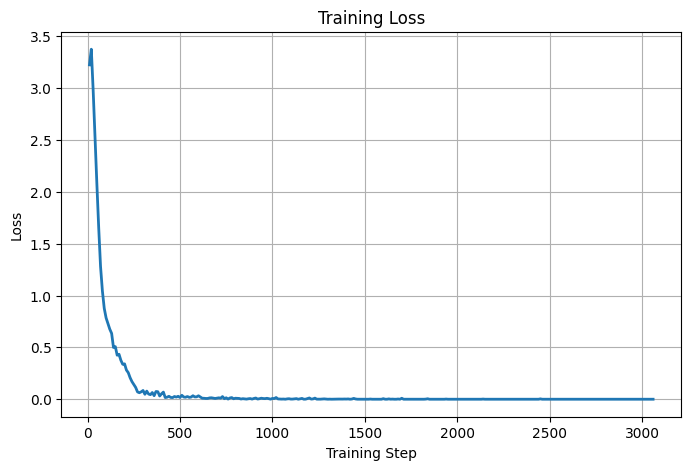

In [53]:
import matplotlib.pyplot as plt

loss_df = history.dropna(subset=["loss"])

plt.figure(figsize=(8,5))

plt.plot(
    loss_df["step"],
    loss_df["loss"],
    linewidth=2
)

plt.title("Training Loss")
plt.xlabel("Training Step")
plt.ylabel("Loss")

plt.grid(True)

plt.show()

Validation WER

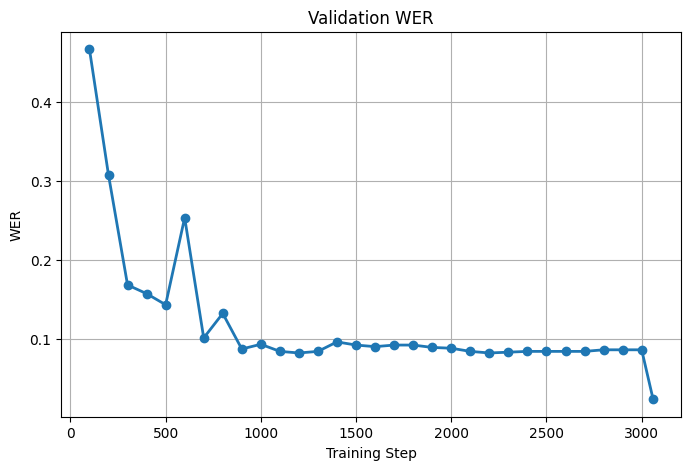

In [54]:
wer_df = history.dropna(subset=["eval_wer"])

plt.figure(figsize=(8,5))

plt.plot(
    wer_df["step"],
    wer_df["eval_wer"],
    marker="o",
    linewidth=2
)

plt.title("Validation WER")
plt.xlabel("Training Step")
plt.ylabel("WER")

plt.grid(True)

plt.show()

Validation CER

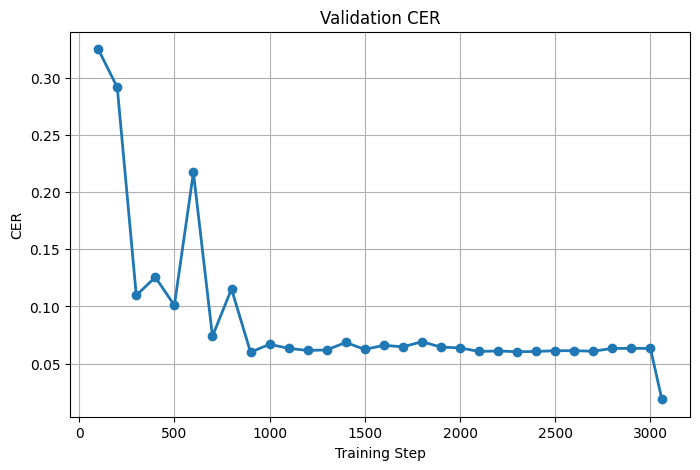

In [55]:
cer_df = history.dropna(subset=["eval_cer"])

plt.figure(figsize=(8,5))

plt.plot(
    cer_df["step"],
    cer_df["eval_cer"],
    marker="o",
    linewidth=2
)

plt.title("Validation CER")
plt.xlabel("Training Step")
plt.ylabel("CER")

plt.grid(True)

plt.show()

# Final Results

In [57]:
import json

with open("hdsd_baseline_results_rawTransliterated.json", "r") as f:
    baseline_results = json.load(f)

print(baseline_results)

{'dataset': 'HDSD', 'model': 'openai/whisper-small', 'language': 'Hindi', 'microphone': 'M2', 'normalization': 'eiâ†’e, iiâ†’i', 'train_samples': 1633, 'val_samples': 159, 'test_samples': 210, 'wer_baseline': 1.3995584988962473, 'cer_baseline': 1.0808835741571168}


In [60]:
BASELINE_WER = baseline_results["wer_baseline"]
BASELINE_CER = baseline_results["cer_baseline"]
FINAL_WER = test_metrics['eval_wer']
FINAL_CER = test_metrics['eval_cer']

wer_improvement = (BASELINE_WER - FINAL_WER) / BASELINE_WER * 100
cer_improvement = (BASELINE_CER - FINAL_CER) / BASELINE_CER * 100

print("=" * 60)
print("Whisper-small Fine-tuning Results")
print("=" * 60)

print(f"Baseline WER : {BASELINE_WER:.4f}")
print(f"Baseline CER : {BASELINE_CER:.4f}")

print()

print(f"Fine-tuned WER : {FINAL_WER:.4f}")
print(f"Fine-tuned CER : {FINAL_CER:.4f}")

print()

print(f"WER Improvement : {wer_improvement:.2f}%")
print(f"CER Improvement : {cer_improvement:.2f}%")
print(f"Best Checkpoint : {trainer.state.best_model_checkpoint}")

Whisper-small Fine-tuning Results
Baseline WER : 1.3996
Baseline CER : 1.0809

Fine-tuned WER : 0.0235
Fine-tuned CER : 0.0188

WER Improvement : 98.32%
CER Improvement : 98.26%
Best Checkpoint : ./whisper-small-hdsd\checkpoint-1200


In [62]:
import json
final_results = {
    "dataset": "HDSD",
    "model": "openai/whisper-small",
    "language": "Hindi",
    "microphone": "M2",
    "normalization": "ei→e, ii→i",

    "train_samples": len(train_df),
    "val_samples": len(val_df),
    "test_samples": len(test_df),

    "wer_baseline": baseline_results["wer_baseline"],
    "cer_baseline": baseline_results["cer_baseline"],

    "wer_finetuned": test_metrics["eval_wer"],
    "cer_finetuned": test_metrics["eval_cer"],

    "wer_improvement_percent":
        (baseline_results["wer_baseline"] - test_metrics["eval_wer"])
        / baseline_results["wer_baseline"] * 100,

    "cer_improvement_percent":
        (baseline_results["cer_baseline"] - test_metrics["eval_cer"])
        / baseline_results["cer_baseline"] * 100,

    "best_validation_wer": trainer.state.best_metric,
    "best_checkpoint": trainer.state.best_model_checkpoint,
    "epochs_trained": trainer.state.epoch
}

with open("hdsd_finetuned_results.json", "w") as f:
    json.dump(final_results, f, indent=2)

print("Saved hdsd_finetuned_results.json")

Saved hdsd_finetuned_results.json


git add .
git commit -m "Refactor fine-tuning notebook and add evaluation artifacts"
git push